### Questão 3

**Enunciado:** Uma academia deseja classificar novos alunos em dois perfis: "Frequente" (A) ou "Ocasional" (B), baseando-se na idade e no gasto médio mensal em suplementos, para oferecer planos personalizados. Aplique o algoritmo de vizinhos mais próximos para classificar um novo aluno de 33 anos que gasta R$ 100. No notebook, plote o gráfico de dispersão destacando os vizinhos e justifique a escolha do valor de K.

**Problema:** Classificar novos alunos da academia nos perfis "Frequente" (A) ou "Ocasional" (B) com base na idade e no gasto médio mensal em suplementos.

**Algoritmo Apropriado:** ``K-Nearest Neighbors (KNN)``.

**Justificativa:** O problema requer a classificação de um novo ponto de dados (aluno) com base na similaridade com o histórico existente. O KNN é ideal para essa tarefa de reconhecimento de padrões, pois é um algoritmo de "aprendizado preguiçoso" (*lazy learning*) que classifica o novo dado com base na classe da maioria de seus vizinhos mais próximos no espaço de características.

#### **Importando as bibliotecas**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

#### **Carregamento do Dataset**

In [11]:
try:
    # Delimitador é vírgula e pula a primeira linha (cabeçalho) com skiprows=1
    dados = np.loadtxt('datasets/dataset_q3.csv', delimiter=',', skiprows=1)

    # Características (Idade, Gasto Suplementos)
    X_train = dados[:, :2]
    
    # Rótulos (1 = Frequente/A, 0 = Ocasional/B)
    y_train = dados[:, 2]

    print("Amostra das características (X_train):")
    print(X_train)

    print("\nAmostra dos rótulos (y_train):")
    print(y_train)

    print("\nNúmero de amostras:", X_train.shape[0])

except FileNotFoundError:
    print("Erro: Arquivo do dataset não encontrado.")
    exit()

Amostra das características (X_train):
[[ 25. 200.]
 [ 45.  50.]
 [ 22. 180.]
 [ 35.  70.]
 [ 28. 210.]
 [ 50.  40.]
 [ 30. 190.]
 [ 42.  60.]
 [ 24. 230.]
 [ 38.  80.]
 [ 26. 170.]
 [ 48.  30.]
 [ 31. 205.]
 [ 40.  55.]
 [ 29. 195.]]

Amostra dos rótulos (y_train):
[1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]

Número de amostras: 15


#### **Funções de Distância e KNN**

In [ ]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos mais próximos de um ponto de teste."""
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))
    
    # Ordena a lista de distâncias em ordem crescente
    distancias.sort(key=lambda x: x[0])
    
    # Retorna os k vizinhos mais próximos (seus rótulos)
    vizinhos = [distancia[1] for distancia in distancias[:k]]
    return vizinhos

def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto majoritário dos vizinhos."""
    contagem_votos = Counter(vizinhos)
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

#### **Realizando Previsões para o Novo Aluno**

In [ ]:
# Novo Aluno: 33 anos, gasta R$ 100
novo_aluno = np.array([33, 100])
k = 3 #Escolhendo k ímpar para evitar empates

# Encontra os vizinhos e faz a previsão
vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_aluno, k)
previsao_final = prever_classificacao(vizinhos_proximos)

# Mapeia o resultado
resultado_texto = "Frequente (A)" if previsao_final == 1 else "Ocasional (B)"

print(f"O novo aluno tem as características: Idade {novo_aluno[0]}, Gasto R$ {novo_aluno[1]}")
print(f"O valor de 'K' escolhido foi: {k}")
print(f"As classes dos {k} vizinhos mais próximos são: {vizinhos_proximos}")
print("----------------------")
print(f"--> Previsão Final: O novo aluno é classificado como {resultado_texto}")

O novo aluno tem as características: Idade 33, Gasto R$ 100
O valor de 'K' escolhido foi: 3
As classes dos 3 vizinhos mais próximos são: [np.float64(0.0), np.float64(0.0), np.float64(0.0)]
----------------------
--> Previsão Final: O novo aluno é classificado como Ocasional (B)


#### **Plotando os Gráficos**

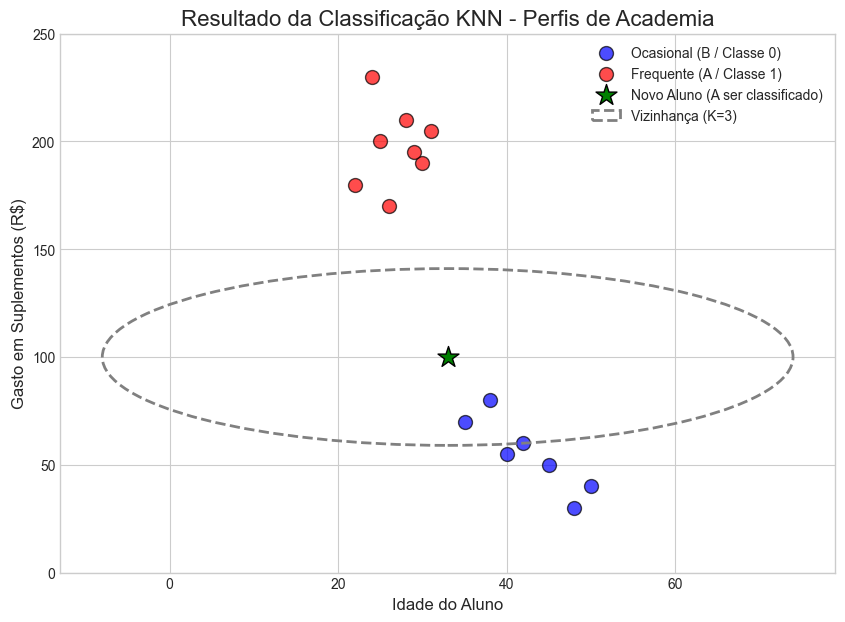

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))

# Plotando os pontos de treinamento
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Ocasional (B / Classe 0)')
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
           c='red', s=100, edgecolor='k', alpha=0.7, label='Frequente (A / Classe 1)')

# Plotando o novo ponto de dados
ax.scatter(novo_aluno[0], novo_aluno[1], c='green', s=250, 
           edgecolor='k', marker='*', label='Novo Aluno (A ser classificado)')

# Destaque para os vizinhos mais próximos
indices_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_aluno) for p in X_train])[:k]
pontos_vizinhos = X_train[indices_vizinhos]

# Desenhando um círculo que engloba os vizinhos
distancia_maxima = calcular_distancia_euclidiana(novo_aluno, pontos_vizinhos[-1])
circulo = plt.Circle(novo_aluno, distancia_maxima, color='gray', fill=False, 
                     linestyle='--', linewidth=2, label=f'Vizinhança (K={k})')
ax.add_artist(circulo)

# Ajustando os limites dos eixos para que o círculo inteiro caiba no gráfico
ax.set_xlim(novo_aluno[0] - distancia_maxima - 5, novo_aluno[0] + distancia_maxima + 5)
ax.set_ylim(0, 250)

# Configurações
ax.set_title('Resultado da Classificação KNN - Perfis de Academia', fontsize=16)
ax.set_xlabel('Idade do Aluno', fontsize=12)
ax.set_ylabel('Gasto em Suplementos (R$)', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True)
plt.show()

### **Interpretação dos Resultados**

A escolha do valor **$K = 3$** foi feita utilizando um número ímpar, prática recomendada para evitar empates em problemas de classificação binária. Ao aplicar a distância Euclidiana, o algoritmo verificou os três registros mais próximos ao novo aluno (idade 33, gasto R$ 100).

Se escolhêssemos um **$K$ muito grande** (ex: *$K = 15$*), o modelo avaliaria todo o conjunto de dados simultaneamente, o que suavizaria demasiadamente os limites de decisão. Em outras palavras, isso causaria um problema de subajuste (*underfitting*), fazendo o algoritmo classificar o novo aluno simplesmente pela classe dominante do dataset global, ignorando as particularidades do perfil mais semelhante a ele.